 # REGRESIÓN LINEAL MULTIPLE

## 1 - IMPORTAMOS LIBRERIAS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2 - CARGAMOS DATASET

In [2]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/housing/housing.data',header=None,sep=r'\s+')
df.columns =  ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df.head(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## 3 - CORRELACIONES

In [3]:
plt.rcParams['figure.figsize'] = (12, 8)

<Axes: >

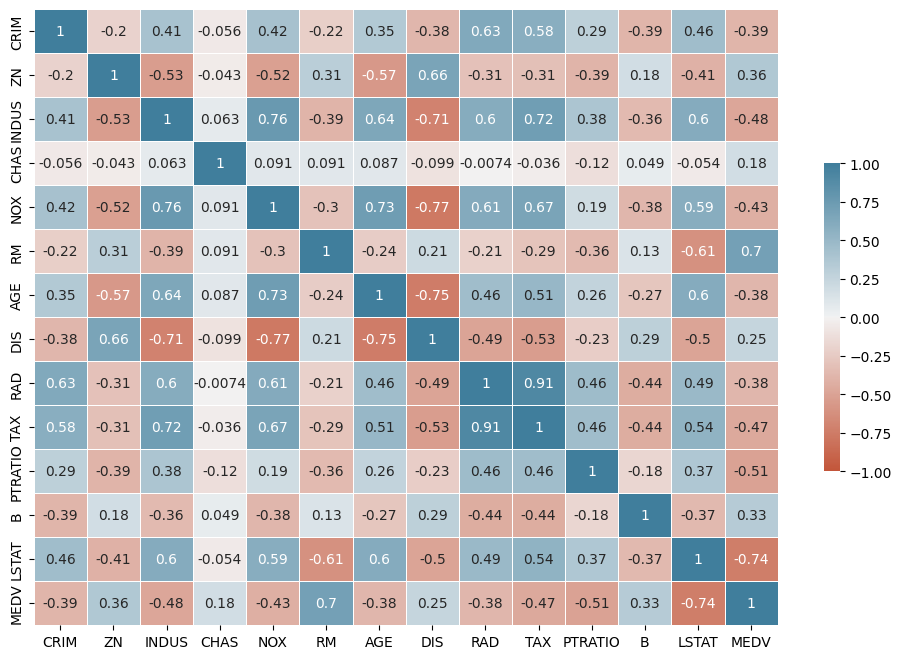

In [4]:
sns.heatmap(
    data=df.corr(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

## 4 - CREAMOS UN MAPA DE CALOR DE LA VARIABLE DEPENDIENTE MEDV CONTRA TODAS LAS DEMAS

In [5]:
corr_matrix = df.corr()
corr_medv = corr_matrix[['MEDV']].sort_values(by='MEDV',ascending=False)
corr_medv

,MEDV
MEDV,1.000000
RM,0.695360
ZN,0.360445
B,0.333461
DIS,0.249929
CHAS,0.175260
AGE,-0.376955
RAD,-0.381626
CRIM,-0.388305
NOX,-0.427321


<Axes: >

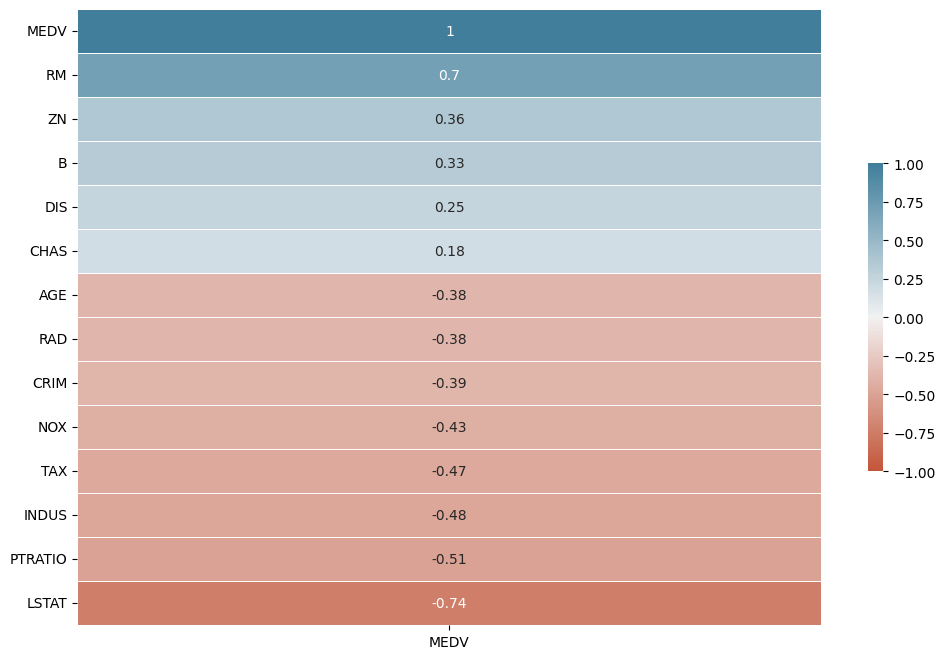

In [6]:
sns.heatmap(
    data=corr_medv,
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'shrink': 0.5},
    annot=True
)

In [7]:
cols = corr_medv.index.tolist()
cols.remove('MEDV')
cols

['RM',
 'ZN',
 'B',
 'DIS',
 'CHAS',
 'AGE',
 'RAD',
 'CRIM',
 'NOX',
 'TAX',
 'INDUS',
 'PTRATIO',
 'LSTAT']

## 5 - CREAMOS UN MODELO DE REGRESIÓN LINEAL SIMPLE PARA X = RM Y = MEDV

## 1 - DEFINIR VARIABLE X y Y

* X = RM(PROMEDIO DE HABITACIONES EN EL DEPARTAMENTO)
* Y = MEDV(VALOR PROMEDIO DEL DEPARTAMENTO)

In [8]:
X = df[cols].values
y = df['MEDV'].values.reshape(-1,1)

In [10]:
X

array([[  6.575,  18.   , 396.9  , ...,   2.31 ,  15.3  ,   4.98 ],
       [  6.421,   0.   , 396.9  , ...,   7.07 ,  17.8  ,   9.14 ],
       [  7.185,   0.   , 392.83 , ...,   7.07 ,  17.8  ,   4.03 ],
       ...,
       [  6.976,   0.   , 396.9  , ...,  11.93 ,  21.   ,   5.64 ],
       [  6.794,   0.   , 393.45 , ...,  11.93 ,  21.   ,   6.48 ],
       [  6.03 ,   0.   , 396.9  , ...,  11.93 ,  21.   ,   7.88 ]])

## 1.1 DIVIDIR DATASET EN TRAIN Y TEST

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [13]:
print(f' X_train(valores de X para entrenamiento) : {X_train.shape[0]}')
print(f' y_train(valores de y para entrenamiento) : {y_train.shape[0]}')
print(f' X_test(valores de X para prueba) : {X_test.shape[0]}')
print(f' y_test(valores de y para prueba) : {y_test.shape[0]}')

 X_train(valores de X para entrenamiento) : 354
 y_train(valores de y para entrenamiento) : 354
 X_test(valores de X para prueba) : 152
 y_test(valores de y para prueba) : 152


# CALCULAMOS PROMEDIO Y STD

In [14]:
print(f'Promedio de X_train : {X_train.mean()}')
print(f'Desviación standard de X_train : {X_train.std()}')

Promedio de X_train : 70.18538399608865
Desviación standard de X_train : 145.01280156043381


## 1.2 ESTANDARIZAMOS VALORES CON STANDARSCALER

In [15]:
from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
X_train = sc_x.fit_transform(X_train)
X_test = sc_x.transform(X_test)

sc_y = StandardScaler()
y_train = sc_y.fit_transform(y_train)
y_test = sc_y.transform(y_test)

In [16]:
print(f'Promedio de X_train : {X_train.mean()}')
print(f'Desviación standard de X_train : {X_train.std()}')

Promedio de X_train : 1.426643824081557e-15
Desviación standard de X_train : 1.0000000000000002


## 2 - IMPORTAR LIBREARIAS DE SKLEARN

In [17]:
from sklearn.linear_model import LinearRegression

## 3 - CREAMOS EL MODELO Y LO ENTRENAMOS CON LA DATA

In [19]:
slr = LinearRegression()
slr.fit(X_train,y_train)
y_pred = slr.predict(X_test)

## 4 - GRAFICAMOS LO REAL VS LOS PREDICHO

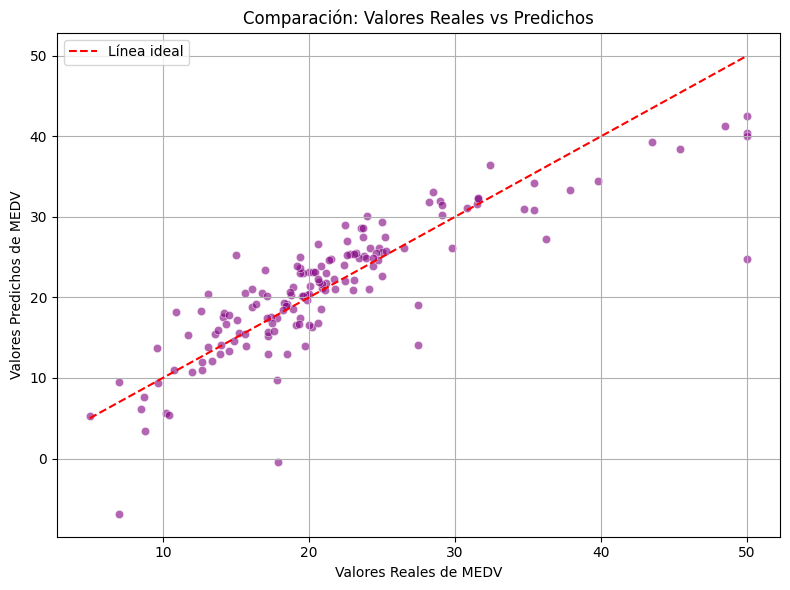

In [20]:
# Invertimos la escala para llevar y_test y y_pred a sus valores originales
y_test_real = sc_y.inverse_transform(y_test)
y_pred_real = sc_y.inverse_transform(y_pred)

# Gráfico
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_real.flatten(), y=y_pred_real.flatten(), color='purple', alpha=0.6)
plt.plot([y_test_real.min(), y_test_real.max()],
         [y_test_real.min(), y_test_real.max()],
         color='red', linestyle='--', label='Línea ideal')

plt.xlabel('Valores Reales de MEDV')
plt.ylabel('Valores Predichos de MEDV')
plt.title('Comparación: Valores Reales vs Predichos')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 6 - METRICAS DEL MODELO

In [21]:
import sklearn.metrics as metrics

# ERROR CUADRATICO MEDIO
mse = metrics.mean_squared_error(y_test,y_pred)
# R2 Coeficiente de determinación
r2 = metrics.r2_score(y_test,y_pred)

print(f'El error cuadratico medio(MSE) es de {round(mse,4)}')
print(f'El coeficiente de determinación(R2) es de {round(r2,4)}')

El error cuadratico medio(MSE) es de 0.2448
El coeficiente de determinación(R2) es de 0.7112


# 7 - PROBAMOS UNA PREDICCIÓN CON NUEVOS DATOS

In [23]:
X_new = np.array([[7.0, 20.0, 390.0, 4.5, 1, 60.0, 3, 0.05, 0.5, 300.0, 10.0, 2.0, 6.0]])

# Asegurarse de que X_new tiene el mismo número de características que X_train
# Las características en 'cols' son: ['RM', 'ZN', 'B', 'DIS', 'CHAS', 'AGE', 'RAD', 'CRIM', 'NOX', 'TAX', 'INDUS', 'PTRATIO', 'LSTAT']
# Revisa que las columnas de X_new coincidan con 'cols' en orden y número.
# Para este ejemplo, estoy asumiendo que el orden de las columnas en X_new es el mismo que en 'cols'.
# El ejemplo proporcionado en X_new tiene 13 valores, que coincide con la longitud de 'cols'.

# Escalar los nuevos datos
X_new_scaled = sc_x.transform(X_new)

# Realizar la predicción
y_new_pred_scaled = slr.predict(X_new_scaled)

# Invertir la escala para obtener el valor real
y_new_pred_real = sc_y.inverse_transform(y_new_pred_scaled)

print(f"El valor de MEDV predicho para los nuevos datos es: {y_new_pred_real[0][0]:.2f}")

El valor de MEDV predicho para los nuevos datos es: 47.37
